#### Sunwoo Lee
#### 25th February 2026

# Assignment 2 - Feature Selection and Dimensionality Reduction on High-Dimensional Gene Expression Data Using gene_expression.csv

## Assignment Imports

In [227]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## PART I: Exploratory Data Analysis (EDA)

### 1) Dataset Overview

#### 1.1 Load the dataset using pandas

In [3]:
# Loading Dataset
# df = pd.read_csv("gene_expression.csv")

print("✅ Dataset Loaded")

✅ Dataset Loaded


#### 1.2 Display:
- Dataset shape (rows × columns)
- First 5 rows
- Data types of all columns

In [97]:
print(f"Dataset shape (rows × columns): {df.shape}\n")
print(df.head())
print(f"\nData Types:\n{df.dtypes}")

Dataset shape (rows × columns): (801, 20533)

       Var1  gene_0    gene_1    gene_2    gene_3     gene_4  gene_5  \
0  sample_0     0.0  2.017209  3.265527  5.478487  10.431999       0   
1  sample_1     0.0  0.592732  1.588421  7.586157   9.623011       0   
2  sample_2     0.0  3.511759  4.327199  6.881787   9.870730       0   
3  sample_3     0.0  3.663618  4.507649  6.659068  10.196184       0   
4  sample_4     0.0  2.655741  2.821547  6.539454   9.738265       0   

     gene_6    gene_7  gene_8  ...  gene_20522  gene_20523  gene_20524  \
0  7.175175  0.591871     0.0  ...    8.210257    9.723516    7.220030   
1  6.816049  0.000000     0.0  ...    7.323865    9.740931    6.256586   
2  6.972130  0.452595     0.0  ...    8.127123   10.908640    5.401607   
3  7.843375  0.434882     0.0  ...    8.792959   10.141520    8.942805   
4  6.566967  0.360982     0.0  ...    8.891425   10.373790    7.181162   

   gene_20525  gene_20526  gene_20527  gene_20528  gene_20529  gene_20530  \

#### 1.3 Report:
- Total number of samples
- Total number of gene features (exclude the Class column)
- Number of missing values (if any)

In [95]:
num_samples = df.shape[0]
print("Total number of samples:", num_samples)

num_gene_features = df.drop(columns=["Class"]).shape[1]
print("Total number of gene features:", num_gene_features)

missing_values = df.isnull().sum().sum()
print("Total number of missing values:", missing_values)

Total number of samples: 801
Total number of gene features: 20532
Total number of missing values: 0


### 2) Class Label Analysis

#### 2.1 Count samples per class using value_counts()

In [93]:
# Count samples per cancer type
class_counts = df["Class"].value_counts()

print(f"Samples per class:\n{class_counts}")

Samples per class:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


#### 2.2 Create a bar plot showing the distribution of classes

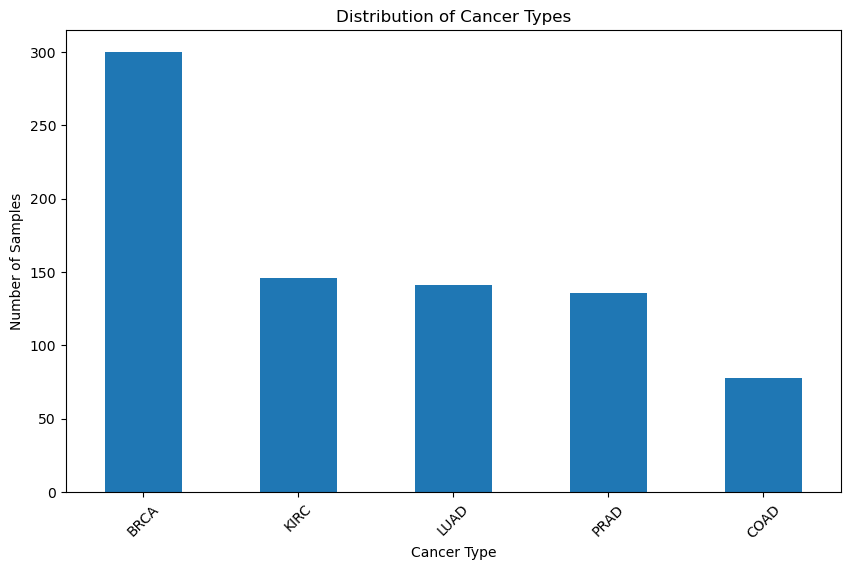

In [84]:
plt.figure(figsize=(10,6))
class_counts.plot(kind='bar')
plt.title("Distribution of Cancer Types")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

#### 2.3 In your written analysis, address:
1. Is there class imbalance? (Define what you consider balanced/imbalanced)
2. Which class has the most samples? Which has the least?
3. How might class imbalance affect downstream analysis?

##### Answer
1. Because BRCA, being the biggest, has 3 times the amount of samples than COAD, being the smallest, there is class imbalance.
2. BRCA has the most samples, at 300, and COAD has the least, at 78.
3. Since there is a class imbalance, the analysis might show a bias classifier towards the bigger class, resulting in a possible misclassification of smaller classes. 

### 3) Gene Expression Characteristics

#### 3.1 Select 5 random genes (e.g., gene_100, gene_500, gene_1000, gene_5000, gene_10000)

In [99]:
genes = ["gene_100", "gene_500", "gene_1000", "gene_5000", "gene_10000"]

selected_df = df[genes]
selected_df.head()

,gene_100,gene_500,gene_1000,gene_5000,gene_10000
0,9.067588,8.607290,10.282579,3.826406,1.598651
1,11.463070,6.439124,9.816923,1.706508,3.962401
2,11.520388,7.972733,9.701637,1.074163,0.000000
3,10.582518,6.875805,10.301290,1.931418,2.175652
4,10.803849,6.382652,10.275636,3.815217,3.068860


#### 3.2 Create histograms for these 5 genes (can be subplots or separate)

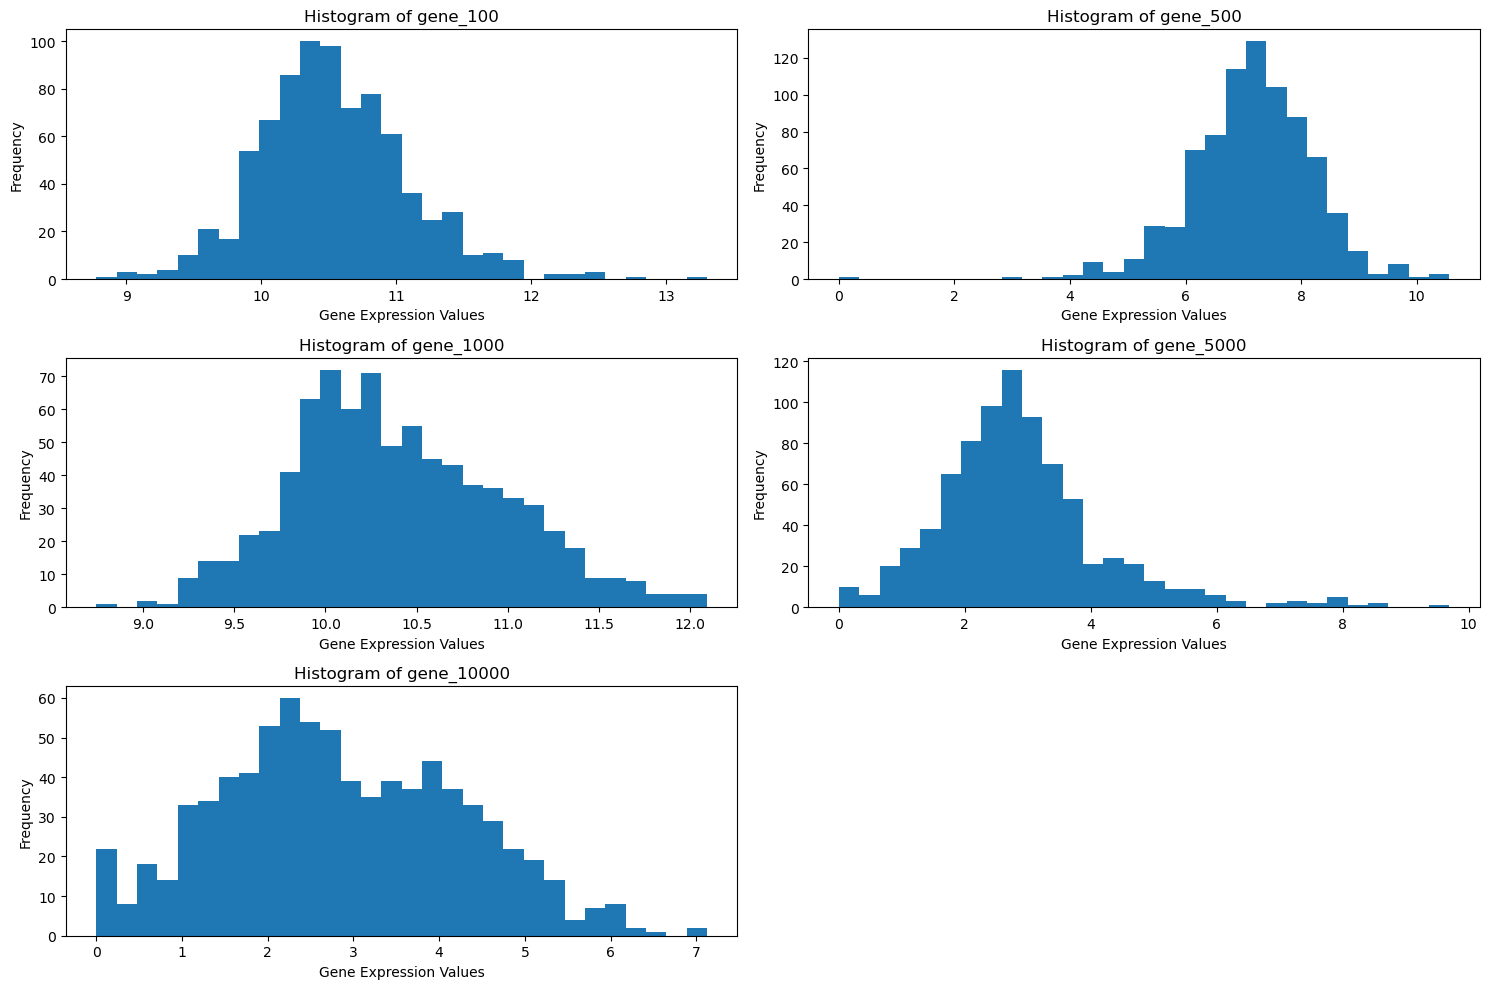

In [105]:
plt.figure(figsize=(15,10))

for i, gene in enumerate(genes):
    plt.subplot(3, 2, i+1)
    plt.hist(df[gene], bins=30)
    plt.title(f"Histogram of {gene}")
    plt.xlabel("Gene Expression Values")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### 3.3 Compute and report:
- Mean and standard deviation for each gene
- Minimum and maximum values

In [107]:
stats = selected_df.describe().T
stats = stats[["mean", "std", "min", "max"]]

print(stats)

                 mean       std       min        max
gene_100    10.536878  0.558500  8.780389  13.303938
gene_500     7.153362  1.038016  0.000000  10.569239
gene_1000   10.401339  0.578472  8.744989  12.090645
gene_5000    2.876082  1.320473  0.000000   9.696780
gene_10000   2.850353  1.410628  0.000000   7.125062


#### 3.4 In your written analysis, discuss:
1. Are distributions approximately normal or skewed?
2. Are there many zero/near-zero values?
3. Do different genes have different scales?
4. Conclusion: Is data standardization/normalization necessary? Why?

##### Answer
1. They are all skewed.
2. No, majority of the values are well above 0.
3. Yes, the genes have differing scales.
4. Yes, standardization/normalization is necessary because each gene's mean, std, and range differ significantly to where genes with larger scales or higher variability could disproportionately influence model training. By standardizing, each gene is able to contribute equally to analysis down the line.

## PART II: Feature Selection

### 1) Apply Feature Selection Methods

In [113]:
# Separate features to only include genes
X = df.drop(columns=["Class", "Var1"])

#### 1.1 Variance Threshold
- Compute variance for each gene
- Rank genes by variance (high to low)

In [127]:
# Compute variance for each gene
gene_variances = X.var()

# Sort variances descending
ranked_variances = gene_variances.sort_values(ascending=False)

# Test to see it worked
ranked_variances.head()

gene_9176     44.763849
gene_9175     36.361940
gene_15898    34.503915
gene_15301    33.458776
gene_15589    31.325845
dtype: float64

#### 1.2 Pearson Correlation Coefficient
- Encode class labels numerically
- Compute absolute correlation between each gene and the class label
- Rank by absolute correlation value

In [131]:
# Encode categorical cancer types
le = LabelEncoder()
y_encoded = le.fit_transform(df["Class"])

# Compute correlation for each gene
correlations = X.apply(lambda gene: gene.corr(pd.Series(y_encoded)))

# Take absolute value
abs_correlations = correlations.abs()

ranked_corr = abs_correlations.sort_values(ascending=False)

# Test to see it worked
ranked_corr.head()

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


gene_17801    0.850083
gene_89       0.795129
gene_19339    0.779375
gene_16372    0.773608
gene_6611     0.758352
dtype: float64

#### 1.3 Chi-Square Test
- Compute chi-square statistic for each gene with respect to class labels
- Rank genes by chi-square scores

In [143]:
chi_scores, p_values = chi2(X, y_encoded)

chi_df = pd.DataFrame({
    "Gene": X.columns,
    "Chi2_Score": chi_scores
})

# Rank genes (high → low chi-square score)
chi_df_sorted = chi_df.sort_values(by="Chi2_Score", ascending=False)

# Test to see it worked
chi_df_sorted.head()

,Gene,Chi2_Score
9176,gene_9176,8580.566498
9175,gene_9175,7363.380532
15898,gene_15898,6902.074640
220,gene_220,6333.703681
219,gene_219,6259.461507


#### 1.4 Mutual Information
- Compute mutual information between each gene and the class label
- Rank genes by mutual information scores

In [148]:
mi_scores = mutual_info_classif(
    X,
    y_encoded,
    random_state=42
)

mi_df = pd.DataFrame({
    "Gene": X.columns,
    "MI_Score": mi_scores
})

mi_df_sorted = mi_df.sort_values(by="MI_Score", ascending=False)

# Test to see it worked
mi_df_sorted.head()

,Gene,MI_Score
7964,gene_7964,0.962183
18381,gene_18381,0.881667
17109,gene_17109,0.859675
5407,gene_5407,0.830510
18746,gene_18746,0.809857


### 2) Report Top Genes

#### 2.1 For each method, create tables showing:
- Top 3 genes (gene names + scores)
- Top 5 genes (gene names + scores)
- Top 10 genes (gene names + scores)

In [154]:
# Variance Method
variance_df = ranked_variances.reset_index()
variance_df.columns = ["Gene", "Variance"]

top3_var = variance_df.head(3)
top5_var = variance_df.head(5)
top10_var = variance_df.head(10)

print("Top 3 Variance")
display(top3_var)

print("Top 5 Variance")
display(top5_var)

print("Top 10 Variance")
display(top10_var)

# Pearson Correlation Method
corr_df = ranked_corr.reset_index()
corr_df.columns = ["Gene", "Absolute_Correlation"]

top3_corr = corr_df.head(3)
top5_corr = corr_df.head(5)
top10_corr = corr_df.head(10)

print("Top 3 Pearson")
display(top3_corr)

print("Top 5 Pearson")
display(top5_corr)

print("Top 10 Pearson")
display(top10_corr)

# Chi-Square Method
top3_chi = chi_df_sorted.head(3)
top5_chi = chi_df_sorted.head(5)
top10_chi = chi_df_sorted.head(10)

print("Top 3 Chi-Square")
display(top3_chi)

print("Top 5 Chi-Square")
display(top5_chi)

print("Top 10 Chi-Square")
display(top10_chi)

# Mutual Information Method
top3_mi = mi_df_sorted.head(3)
top5_mi = mi_df_sorted.head(5)
top10_mi = mi_df_sorted.head(10)

print("Top 3 Mutual Information")
display(top3_mi)

print("Top 5 Mutual Information")
display(top5_mi)

print("Top 10 Mutual Information")
display(top10_mi)

# Summary Table
top10_sets = {
    "Variance": set(top10_var["Gene"]),
    "Pearson": set(top10_corr["Gene"]),
    "ChiSquare": set(top10_chi["Gene"]),
    "MutualInfo": set(top10_mi["Gene"])
}

comparison = []

for m1, m2 in itertools.combinations(top10_sets.keys(), 2):
    overlap = len(top10_sets[m1].intersection(top10_sets[m2]))
    comparison.append([m1, m2, overlap])

comparison_df = pd.DataFrame(comparison, columns=["Method 1", "Method 2", "Shared Top-10 Genes"])
comparison_df

Top 3 Variance


,Gene,Variance
0,gene_9176,44.763849
1,gene_9175,36.361940
2,gene_15898,34.503915


Top 5 Variance


,Gene,Variance
0,gene_9176,44.763849
1,gene_9175,36.361940
2,gene_15898,34.503915
3,gene_15301,33.458776
4,gene_15589,31.325845


Top 10 Variance


...

Top 5 Mutual Information


,Gene,MI_Score
7964,gene_7964,0.962183
18381,gene_18381,0.881667
17109,gene_17109,0.859675
5407,gene_5407,0.830510
18746,gene_18746,0.809857


Top 10 Mutual Information


,Gene,MI_Score
7964,gene_7964,0.962183
18381,gene_18381,0.881667
17109,gene_17109,0.859675
5407,gene_5407,0.830510
18746,gene_18746,0.809857
6816,gene_6816,0.806660
8349,gene_8349,0.798966
7992,gene_7992,0.794504
5576,gene_5576,0.794097
6593,gene_6593,0.787175


,Method 1,Method 2,Shared Top-10 Genes
0,Variance,Pearson,0
1,Variance,ChiSquare,3
2,Variance,MutualInfo,0
3,Pearson,ChiSquare,0
4,Pearson,MutualInfo,0
5,ChiSquare,MutualInfo,0


#### 2.2 Written Analysis (must address):
1. Which genes appear consistently across multiple methods?
2. Which methods produce very different rankings?
3. What might explain the differences between methods?
4. If you had to choose one method, which would it be and why?

##### Answer
1. 3 Genes only appeared on 2 methods, being gene_9176, gene_9175, and gene_15898
2. The Person Correlation method and the Mutual Information method did not have any overlap with other methods, thus producing very different rankings.
3. Each method uses different mathematical assumptions. Variance just identifies the highly variable genes, Pearson correlation captures only linear relationships, Chi square measures statistical dependencies but is influenced by magniture, and Mutual information captures both linear and non-linear dependencies. Due to these differing methods, there is such few overlap.
4. Mutual Information method is best overall since it is able to handle multi-class data and be able to capture linear and non-linear relationships, without making assumptions on the data's structure.

## PART III: Dimensionality Reduction & Visualization

### 1) Principal Component Analysis (PCA)

#### 1.1 Standardize the data using StandardScaler

In [182]:
X = df.drop(columns=["Class", "Var1"])
Y = df[["Class", "Var1"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original data shape: {X.shape}")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data mean (should be ~0): {X_scaled.mean():.6f}")
print(f"Scaled data std (should be ~1): {X_scaled.std():.6f}")

Original data shape: (801, 20531)
Scaled data shape: (801, 20531)

Scaled data mean (should be ~0): 0.000000
Scaled data std (should be ~1): 0.993476


#### 1.2 Apply PCA (keep all components initially)

In [184]:
pca = PCA()  # default keeps min(n_samples, n_features)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"PCA components: {X_pca.shape[1]}")

Original dimensions: 20531
PCA components: 801


#### 1.3 Create two plots:
- Plot 1: Explained variance ratio per component (first 50 components)
- Plot 2: Cumulative explained variance (first 50 components)

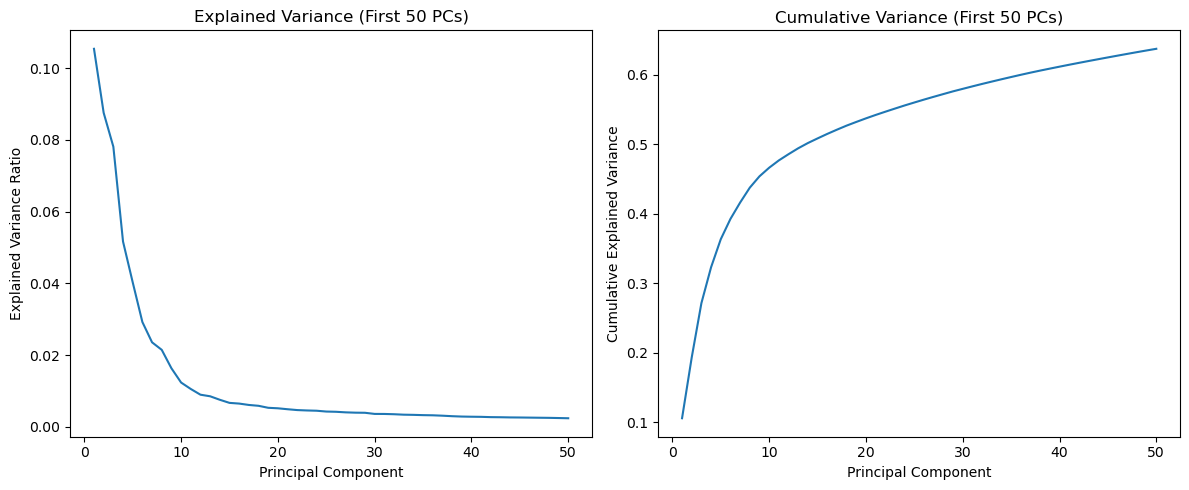

In [198]:
explained_variance = pca.explained_variance_ratio_

explained_variance_50 = explained_variance[:50]
cumulative_variance_50 = np.cumsum(explained_variance[:50])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Explained Variance Ratio
axes[0].plot(range(1, 51), explained_variance_50)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Explained Variance (First 50 PCs)")

# Plot 2: Cumulative Explained Variance
axes[1].plot(range(1, 51), cumulative_variance_50)
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance (First 50 PCs)")

plt.tight_layout()
plt.show()

#### 1.4 Create scatter plot: PC1 vs. PC2, colored by class label (include legend)

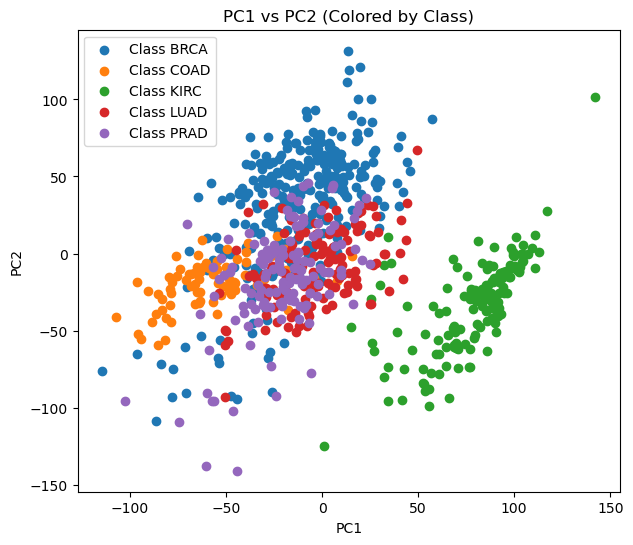

In [204]:
# PC1 and PC2
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# Unique class labels
y = df['Class']
y_values = np.ravel(y)
classes = np.unique(y_values)

plt.figure(figsize=(7,6))

for cls in classes:
    mask = y_values == cls
    plt.scatter(pc1[mask], pc2[mask], label=f"Class {cls}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 (Colored by Class)")
plt.legend()
plt.show()

#### 1.5 Written Analysis (must address):
1. How many components are needed to capture 90% of variance? 95%?
2. How much variance is explained by the first 2 components?
3. Do classes separate well in the PC1-PC2 plot?
4. Which classes overlap? Which are distinct?
5. What are the limitations of PCA for interpretability?

In [223]:
print("Components needed to capture 90%:", np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.90)[0][0] + 1)
print("Components needed to capture 95%:", np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1)
print("Total number of PCA components:", X_pca.shape[1])

print("Explained variance by first 2 components:", np.sum(pca.explained_variance_ratio_[:2]))

Components needed to capture 90%: 373
Components needed to capture 95%: 530
Total number of PCA components: 801
Explained variance by first 2 components: 0.19294013819924247


##### Answer
1. It would require 373 components to capture 90% and 530 components to capture 95%.
2. The first 2 components explain about 0.193%, indicating that the data is not strongly compressible into just 2 dimensions.
3. Aside from KIRC (green), the components do not separate well in 2D.
4. PRAD (purple) and LUAD (red) overlap the most, practically being on top of each other, while BRCA (blue) and COAD (orange) are either slightly above or to the left of the PRAD and LUAD blob, but they still strongly overlap. KIRC is the only one that is distincly separated with minor overlap.
5. PCA is limited to capturing linear relationships and not nonlinear ones. PCA also maximizes variance and not class separability which results in strong overlapping.

### 2) t-SNE Visualization

#### 2.1 Apply t-SNE with at least two different perplexity values (e.g., 30 and 50)
- ~~Option A: Apply t-SNE on original standardized data~~
- Option B: Apply t-SNE on PCA-reduced data (first 50 components) — recommended for speed

In [235]:
X_pca_50 = X_pca[:, :50]

# t-SNE (perplexity = 30)
tsne_30 = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_30 = tsne_30.fit_transform(X_pca_50)

# t-SNE (perplexity = 50)
tsne_50 = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne_50 = tsne_50.fit_transform(X_pca_50)

#### 2.2 Create 2D scatter plots for each perplexity, colored by class label

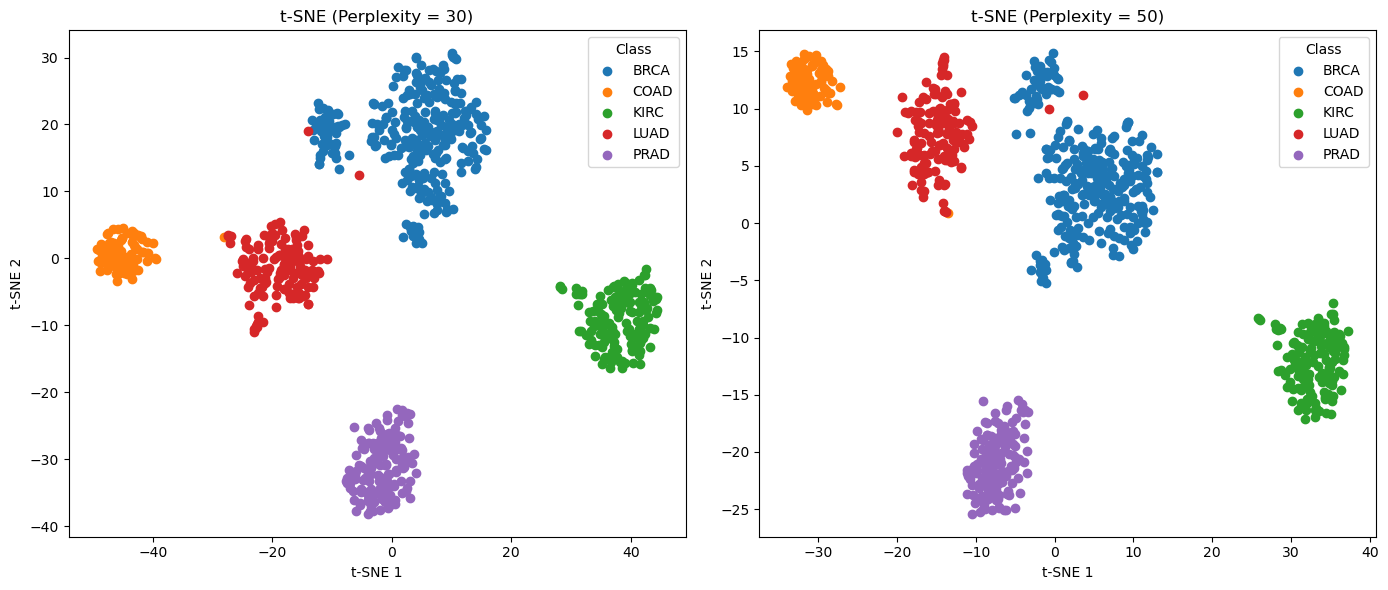

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Perplexity = 30
for cls in classes:
    mask = y_values == cls
    axes[0].scatter(X_tsne_30[mask, 0], X_tsne_30[mask, 1], label=str(cls))
axes[0].set_title("t-SNE (Perplexity = 30)")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(title="Class")

# Plot 2: Perplexity = 50
for cls in classes:
    mask = y_values == cls
    axes[1].scatter(X_tsne_50[mask, 0], X_tsne_50[mask, 1], label=str(cls))
axes[1].set_title("t-SNE (Perplexity = 50)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

#### 2.3 Written Analysis (must address):
1. How does perplexity affect the visualization?
2. Are clusters more separated than in PCA?
3. Do you observe local structure (nearby points) vs. global structure?
4. Which classes form tight clusters? Which are scattered?
5. Compare t-SNE to PCA: which provides better class separation?

##### Answer
1. For lower perplexities, t-SNE focuses more on local structures, often producing tighter clusters and have strong separation between small groups. On the other hand, for higher perplexities, t-SNE considers a broader neighborhood, producing smoother and more globally balaned and cohesive groupings.
2. Compared to the PC1 vs PC2 scatter plot, t_SNE shows much clearer separations between classes and only 2 LUAD (red) dots overlap with BRCA (blue), while no other color are even near each other.
3. In this case, a local structure can be observed as the class clusters are tightly packed together with strong separations. It would not be considered gloval structure, as multiple clusters' position shifts between going from low to high (30 to 50), indicating that global structure is not preserved.
4. In these graphs, it shows that COAD (orange), PRAD (purple), and KIRC (green) form tight clusters, while LUAD (red) and BRCA (blue) have some scattered dots.
5. Because PCA had significant overlap while t-SNE showed clear cluster separations, t-SNE provides better class separation than PCA does.

## PART IV: Feature Selection vs. Dimensionality Reduction

1. For identifying important genes:
   - Which approach is better? Why?
   - Can you interpret PCA components as specific genes?
2. For visualizing class separation:
   - Which technique worked best?
   - Does visualization quality matter for your analysis goals?
3. Interchangeability:
   - Can dimensionality reduction replace feature selection?
   - When would you use one vs. the other?
4. Biomarker discovery:
   - If your goal is to discover biomarkers (genes associated with cancer), which approach would you use?
   - Justify your choice
5. Role of class labels:
   - How does having labeled data influence your choice of method?
   - Which methods are supervised vs. unsupervised?

### Discussion
1. For identifying import genes, supervised feature selection methods are more appropriate than dimensionality reduction techniques such as PCA. Supervised approaches, such as Pearson correlation with class labels, chi-squared test, or mutual information, directly measure the relationship between individual genes and the outcome variable. Because they incorporate label information, these methods prioritize genes that are statistically associated with disease status. In contrast, PCA is an unsupervised technique that identifies directions of maximum variance in the data without considering class labels. High variance does not necessarily imply biological relevance or association with cancer. Therefore, while PCA may highlight genes contributing to global variability, it does not specifically identify disease-related genes.
2. For visualizing class separation, dimensionality reduction techniques such as t-SNE are particularly useful. t-SNE provides a nonlinear low-dimensional projection that is well-suited for high-dimensional gene expression data, often revealing cluster structure more clearly than linear methods. Because t-SNE preserves local neighborhood relationships, it can highlight subtle differences between cancer and normal samples that may not be apparent in PCA. However, t-SNE is still an unsupervised technique and does not incorporate class labels during embedding. As a result, while separation may appear visually strong, it is not explicitly optimized for class discrimination. Visualization quality does matter, but primarily as an exploratory tool. Clear separation can indicate meaningful structure and potential predictive signal, but visualization alone does not confirm biological relevance. Statistical validation and predictive modeling are still necessary.
3. Dimensionality reduction and feature selection are not interchangeable. Feature selection retains the original genes and preserves interpretability, which is essential for biological insight and biomarker identification. In contrast, dimensionality reduction transforms the data into new composite variables, sacrificing direct interpretability in exchange for a more compact representation and reduced noise. Feature selection is preferred when gene-level understanding and biological explanation are important, whereas dimensionality reduction is advantageous for visualization, reducing redundancy among features, or improving computational efficiency in predictive modeling. In practice, the two approaches can be complementary, for example by selecting informative genes first and then applying PCA for visualization or modeling purposes.
4. For biomarker discovery, supervised feature selection is the appropriate choice. Biomarkers must correspond to specific genes that are statistically associated with cancer and biologically interpretable. Methods that directly evaluate gene–label associations provide clear rankings and can be validated experimentally. PCA, while useful for exploratory analysis, does not directly yield interpretable gene candidates.
5. The availability of class labels significantly influences methodological choice. When labeled data are available, supervised methods can directly optimize for disease discrimination and identify predictive features. Without labels, only unsupervised methods such as PCA, clustering, or variance filtering can be applied, limiting interpretability in a disease-specific context. In summary, supervised methods are essential for identifying important genes and discovering biomarkers, whereas unsupervised dimensionality reduction techniques are best suited for exploratory analysis and visualization. Of the ones used in this assignment, the supervised methods are Pearson correlation coefficient, chi-squared test, and mutual information, and the unsupervised methods are Variance threshold, PCA, and t-SNE.

494 words

## PART V: Label-Based Analysis 

1. Identify which classes are easier/harder to separate in visualizations
2. Discuss why certain cancer types might be more distinct
3. Relate findings to feature selection results

### Analysis
1. The classes that show up as clear, tight clusters in t-SNE or PCA plots are easier to separate because their gene expression patterns are more consistent and different from other groups. The ones that overlap a lot are harder to separate, which likely means their data patterns are more similar or more spread out.
2. Some cancer types might look more distinct simply because their gene expression values are very different from the others. If a group has strong, consistent patterns across samples, it will naturally form its own cluster. Groups that come from similar tissues or have similar behavior might look closer together in the plots.
3. When a cancer type is clearly separated in the visualization, it usually matches up with stronger results in supervised feature selection, like higher correlation or mutual information scores. If two classes overlap a lot in the plots, the feature selection results also tend to show weaker differences between them, meaning fewer genes strongly separate those groups.

# Final Reflection

From the exploratory data analysis, I learned that the dataset is highly high-dimensional, with far more genes than samples, which makes feature reduction essential. The gene expression values showed large variability across genes, but high variance alone did not necessarily correspond to class separation. Some genes appeared strongly associated with the class labels, while many others likely contributed to noise. Visualizations also showed that certain classes cluster more clearly than others, suggesting that some cancer types have stronger expression patterns than others. 

Among the feature selection methods used, supervised approaches such as Pearson correlation, chi-squared testing, and mutual information were more aligned with the goal of identifying class-associated genes than variance thresholding. Variance only captures overall spread, whereas the supervised methods incorporate label information. However, no single supervised method can automatically be declared the most effective. Pearson correlation captures linear relationships, mutual information captures both linear and nonlinear dependencies, and chi-squared measures statistical dependence. The best method depends on the underlying relationship between gene expression and labels, which cannot be determined from visualization alone. 

Comparing PCA and t-SNE, PCA is useful for understanding global structure and overall variance in the dataset. It is deterministic and computationally efficient, but it may not clearly separate classes because it does not use label information. t-SNE, on the other hand, often provides clearer clustering by preserving local structure, making it better for visualizing class separation. However, it is sensitive to parameter choices and less interpretable. 

For this problem, I would use both feature selection and dimensionality reduction. Feature selection should come first to retain interpretable genes, followed by dimensionality reduction for visualization or modeling. As future work, I would explore using a supervised classification model to quantitatively evaluate how well the selected genes predict cancer type. 

A solid improvement would be to quantitatively compare the feature selection methods using cross-validation. Specifically, I would select the top half of the genes from Pearson correlation, chi-squared, and mutual information, train the same classifier on each set, and compare metrics like accuracy, F1-score, and ROC-AUC. This would let me objectively decide which method “worked best” instead of relying on visual separation or intuition. 